# Logistic regression — a straight line that answers yes or no

## The story

Arjun maintains the mail gateway at a mid-size company. Ten thousand messages
are already labelled by hand, `SPAM` or `NOT SPAM`, and each one has been boiled
down to four numbers: how many links it contains, how many words, how many
special characters, and whether any word from a known spam list appears.

He had just finished learning `LinearRegression`, so he used it. Turn the label
into 0 and 1, fit a line, and call anything above 0.5 spam.

It fitted, and with a 0.5 cut it was right about 95% of the time, so for a day he
thought he was done. Then the mail team asked for the thing every spam filter
actually needs: **a confidence score**, so borderline messages could go to a
review queue instead of being junked outright.

He printed the raw predictions. `1.162`. `-0.509`. `0.87`. Out of 2 000 test
messages, **441 came back outside the range 0 to 1** — no message is 116% spam,
and none is minus 51% spam. There was no confidence to report. Clipping them to
the range did not help either, because everything piled up at exactly 0 and 1 and
the borderline cases he was trying to find disappeared.

**The problem is the straight line itself.** A line has no ceiling and no floor,
and least squares scores it on how close it gets to 0 and 1 — so a message that
is already obviously spam still pulls the line towards it, because being at 0.8
instead of 1.0 is charged for exactly like a genuine mistake.

Logistic regression keeps the line — the same weighted sum of the four numbers —
and bends its output through a curve that can never leave 0 to 1. Every message
comes back as a real probability, the obviously-spam ones stop pulling, and
Arjun's review queue becomes a threshold he can move whenever he likes.

## The data

Four numeric columns and one text label.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score)

SPAM, HAM, LINE = "#e4572e", "#1f7a8c", "#888888"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10})

dataset = pd.read_csv("../Data/spam_detection.csv")
print(dataset.shape)
print(dataset.label.value_counts())
dataset.head()

(10000, 5)
label
NOT SPAM    7000
SPAM        3000
Name: count, dtype: int64


,num_links,num_words,num_special_chars,has_spammy_keywords,label
0,4,39,15,1,NOT SPAM
1,1,72,4,1,NOT SPAM
2,3,164,5,1,NOT SPAM
3,3,63,5,1,NOT SPAM
4,1,122,1,0,NOT SPAM


**7 000 not spam against 3 000 spam.** Hold on to that ratio — it comes back at
the end.

`LogisticRegression` needs numbers, so the label goes through `LabelEncoder`,
which sorts the distinct values alphabetically and numbers them from zero:

```text
NOT SPAM  ->  0        ("N" before "S")
SPAM      ->  1
```

Which way round it lands matters. Everything the model reports afterwards — the
coefficients, `predict_proba`, the confusion matrix — is phrased as "probability
of class 1", and here class 1 is spam. Check it, never assume it.

In [2]:
le = LabelEncoder()
dataset["label"] = le.fit_transform(dataset["label"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

x = dataset[["num_links", "num_words", "num_special_chars", "has_spammy_keywords"]]
y = dataset["label"]                      # a Series, not a DataFrame — see the note below
dataset.head()

{'NOT SPAM': np.int64(0), 'SPAM': np.int64(1)}


,num_links,num_words,num_special_chars,has_spammy_keywords,label
0,4,39,15,1,0
1,1,72,4,1,0
2,3,164,5,1,0
3,3,63,5,1,0
4,1,122,1,0,0


> The class notebook used `y = dataset[['label']]` with two brackets, which makes
> a one-column **DataFrame**, and sklearn answered with
> `DataConversionWarning: A column-vector y was passed when a 1d array was
> expected`. It still fitted, because sklearn flattened it silently. One bracket
> — `dataset['label']` — gives a Series and the warning goes away. `y.ravel()`
> is the other fix.

## Why the line has to be bent

One picture, two panels. On the left is what Arjun saw: `LinearRegression`
fitted to the 0/1 label on all four columns, and where its predictions land. On
the right is what logistic regression returns instead.

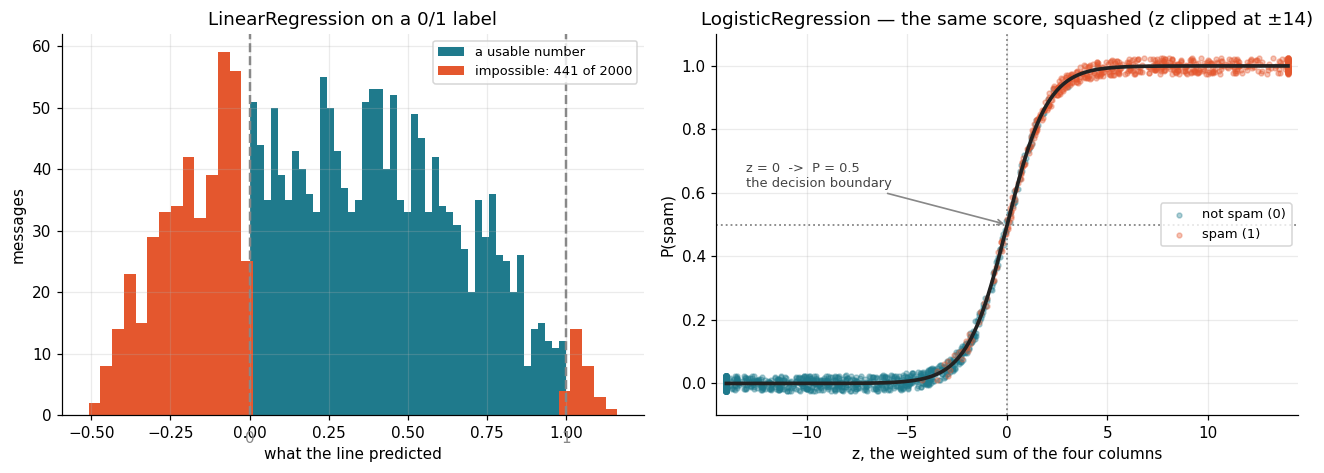

line: predictions run from -0.509 to 1.162   (441 of 2000 outside 0-1)
sigmoid: 0.000 to 1.000   (0 to 1, always)
z runs from -36.0 to 23.0 — any number at all
messages with |z| < 4 (the uncertain middle): 429 of 2000

accuracy, line with a 0.5 cut : 0.9530
accuracy, logistic regression : 0.9595


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, train_size=0.8, random_state=1)

lin = LinearRegression().fit(X_train, y_train)
log = LogisticRegression().fit(X_train, y_train)

raw  = lin.predict(X_test)                   # "0/1" predicted as a plain number
out  = (raw < 0) | (raw > 1)                 # …except when it is not
z    = log.decision_function(X_test)         # the linear part of logistic regression
prob = log.predict_proba(X_test)[:, 1]       # the same thing, through the sigmoid

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.0, 4.4))

ax1.hist(raw[~out], bins=45, color=HAM,  label="a usable number")
ax1.hist(raw[out],  bins=45, color=SPAM, label=f"impossible: {out.sum()} of {len(raw)}")
for v, name in ((0, "0"), (1, "1")):
    ax1.axvline(v, c=LINE, ls="--", lw=1.6)
    ax1.text(v, -4.5, name, color=LINE, fontsize=10, ha="center")
ax1.set(title="LinearRegression on a 0/1 label",
        xlabel="what the line predicted", ylabel="messages")
ax1.legend(fontsize=8.5, loc="upper right")

zoom = 14                                    # z runs to ±36; the bend all happens here
curve_z = np.linspace(-zoom, zoom, 400)
rng = np.random.default_rng(0)
for cls, colour, name in [(0, HAM, "not spam (0)"), (1, SPAM, "spam (1)")]:
    m = y_test.values == cls
    ax2.scatter(np.clip(z[m], -zoom, zoom), prob[m] + rng.uniform(-.025, .025, m.sum()),
                s=10, c=colour, alpha=.35, label=name, zorder=2)
ax2.plot(curve_z, 1 / (1 + np.exp(-curve_z)), c="#222222", lw=2.4, zorder=3)
ax2.axhline(0.5, c=LINE, ls=":", lw=1.2)
ax2.axvline(0.0, c=LINE, ls=":", lw=1.2)
ax2.annotate("z = 0  ->  P = 0.5\nthe decision boundary", xy=(0, .5), xytext=(-13, .62),
             fontsize=8.5, color="#444444",
             arrowprops=dict(arrowstyle="->", color=LINE, lw=1.1))
ax2.set(title=f"LogisticRegression — the same score, squashed (z clipped at ±{zoom})",
        xlabel="z, the weighted sum of the four columns", ylabel="P(spam)",
        ylim=(-.1, 1.1), xlim=(-zoom - .5, zoom + .5))
ax2.legend(fontsize=8.5, loc="center right")

plt.tight_layout(); plt.show()

print(f"line: predictions run from {raw.min():.3f} to {raw.max():.3f}"
      f"   ({out.sum()} of {len(raw)} outside 0-1)")
print(f"sigmoid: {prob.min():.3f} to {prob.max():.3f}   (0 to 1, always)")
print(f"z runs from {z.min():.1f} to {z.max():.1f} — any number at all")
print(f"messages with |z| < 4 (the uncertain middle): {(np.abs(z) < 4).sum()} of {len(z)}")
print()
print(f"accuracy, line with a 0.5 cut : {((raw >= .5).astype(int) == y_test).mean():.4f}")
print(f"accuracy, logistic regression : {log.score(X_test, y_test):.4f}")

**Left panel.** The red bars are the 441 messages the line scored below 0 or
above 1. They are not an edge case — they are a fifth of the test set, and they
are the *confident* predictions, the ones a filter most wants to act on. A line
has nowhere to put "definitely spam" except further and further past 1.

**Right panel.** The same rows, same four columns. `z` on the horizontal axis is
an ordinary linear model and runs from −36 to +23, exactly as unbounded as the
line on the left — the axis is clipped at ±14 because the entire bend happens in
that window. The curve is what fixes it: whatever `z` does, the output stays
between 0 and 1. Blue points sit on the left arm, red on the right, and the
handful climbing the middle are the genuinely uncertain messages — Arjun's review
queue, which now has a number to sort by.

That curve is the **sigmoid**, and it is the only new piece of machinery:

$$P(spam) = \frac{1}{1 + e^{-z}}  \qquad\text{where}\qquad  z = w_1 x_1 + w_2 x_2 + w_3 x_3 + w_4 x_4 + b$$

Read it right to left:

- `z` is a plain linear model — the same shape `LinearRegression` fits. It can be
  any number.
- the sigmoid squashes `z` into 0…1. `z = 0` gives exactly 0.5; large positive
  `z` approaches 1, large negative approaches 0.
- `predict()` then applies the 0.5 cut, which is the same thing as asking
  `z > 0`.

So the decision boundary is still a straight line through the four columns.
Logistic regression is a **linear** model — only its output is curved. That is
also why the two accuracies are close: both draw a straight boundary, and the
sigmoid's advantage is not a cleverer boundary but an output you can read.

The other half of the change is what it is scored on. Least squares charges for
the squared distance to 0 or 1, so it keeps working on rows it already has right.
Logistic regression charges **log loss**, which punishes confident mistakes hard
and barely notices a correct answer that was only just correct — so obvious spam
stops pulling the boundary around.

## Reading the fitted model

The model is already fitted above. This is the class notebook's own call, and
`0.9595` is its number.

In [4]:
print(f"train rows {len(X_train)}   test rows {len(X_test)}")
print(f"accuracy on the test set : {log.score(X_test, y_test):.4f}")
print(f"intercept (b)            : {log.intercept_[0]:.2f}")

weights = pd.DataFrame({
    "column": x.columns,
    "weight (w)": log.coef_[0].round(3),
    "odds x per unit": np.exp(log.coef_[0]).round(2),
    "column sd": x.std().values.round(1),
    "w x sd": (log.coef_[0] * x.std().values).round(2),
}).set_index("column")
weights

train rows 8000   test rows 2000
accuracy on the test set : 0.9595
intercept (b)            : -38.97


,weight (w),odds x per unit,column sd,w x sd
column,,,,
num_links,0.667,1.95,1.4,0.94
num_words,0.187,1.21,56.7,10.58
num_special_chars,1.089,2.97,5.8,6.27
has_spammy_keywords,1.826,6.21,0.5,0.91


Two ways to read the same four numbers, and they disagree.

**`weight (w)`** is how much `z` moves per one extra unit of that column, with
the others held still. By that measure `has_spammy_keywords` is the big one at
1.83 — and since `exp(1.83) = 6.2`, a message containing a listed word has
**six times the odds** of being spam. `num_words` looks negligible at 0.187.

**`w × sd`** tells the opposite story. A unit of `num_words` is one word, and the
column has a standard deviation of 57 words, so a typical swing in message length
moves `z` by about 10.6 — more than any other column. `num_links` has a standard
deviation of 1.4, so its larger-looking weight only moves `z` by about 0.9.

Both are true. A per-unit weight is not an importance unless the columns are on
the same scale, which is the argument for scaling before you try to interpret
coefficients at all. The prediction is unaffected either way — this is only about
reading the model.

The intercept is **−38.97**, far below anything the columns can be. That is the
model saying "assume not spam", and it takes a large positive contribution from
the four columns to climb back over `z = 0`.

## 95.95% — of what?

Here is where the 7 000 / 3 000 split from the top comes back. A model that
answers "not spam" to every single message is right 70% of the time. So the
question is not "is 95.95% high" but "what is it getting wrong".

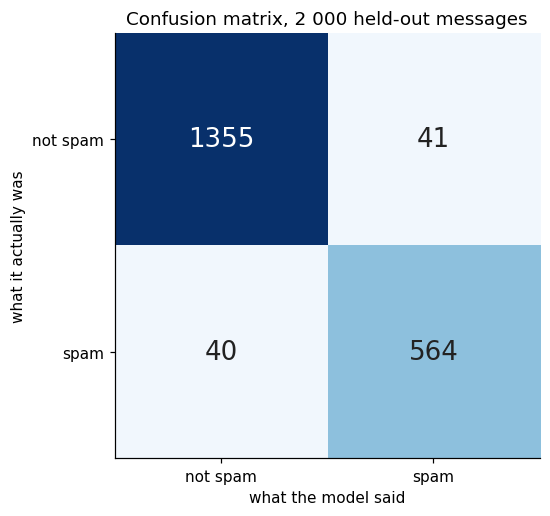

always answer "not spam" : 0.6980
this model               : 0.9595

spam that got through (false negative) : 40
real mail junked        (false positive) : 41

              precision    recall  f1-score   support

    not spam       0.97      0.97      0.97      1396
        spam       0.93      0.93      0.93       604

    accuracy                           0.96      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.96      0.96      0.96      2000



In [5]:
y_pred = log.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
labels = ["not spam", "spam"]

fig, ax = plt.subplots(figsize=(5.6, 4.8))
ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=17,
                color="white" if cm[i, j] > cm.max() * .55 else "#222")
ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=labels, yticklabels=labels,
       xlabel="what the model said", ylabel="what it actually was",
       title="Confusion matrix, 2 000 held-out messages")
ax.grid(False)
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
always_ham = accuracy_score(y_test, np.zeros_like(y_test))
print(f'always answer "not spam" : {always_ham:.4f}')
print(f"this model               : {accuracy_score(y_test, y_pred):.4f}")
print()
print(f"spam that got through (false negative) : {fn}")
print(f"real mail junked        (false positive) : {fp}")
print()
print(classification_report(y_test, y_pred, target_names=labels))

The two error cells are not the same mistake. Spam that got through is an
annoyance; real mail wrongly junked is an invoice nobody saw. Accuracy adds them
together and hides the difference, which is why the confusion matrix is the
report that matters here and `recall` for the spam row is the number Arjun would
actually be held to.

And because the sigmoid hands back a probability rather than a verdict, the 0.5
cut is **yours to move**. Nothing needs refitting.

In [6]:
proba = log.predict_proba(X_test)[:, 1]

print("threshold   spam caught   real mail junked")
for t in (0.30, 0.50, 0.70, 0.90):
    pred = (proba >= t).astype(int)
    c = confusion_matrix(y_test, pred)
    print(f"   {t:.2f}        {c[1, 1]:4d} / {c[1].sum()}        {c[0, 1]:4d}")

threshold   spam caught   real mail junked
   0.30         579 / 604          66
   0.50         564 / 604          41
   0.70         534 / 604          24
   0.90         483 / 604           4


Raise the threshold and fewer innocent messages get junked, at the cost of
letting more spam through. That trade is a business decision, not a modelling
one — and
[ROC and AUC](../../25_ROC_And_AUC/Concept) is how you look at every threshold
at once.

## Saving it

The class notebook ends by writing the fitted model to disk. Four numbers and an
intercept are all that is being stored.

```python
import pickle
pickle.dump(model, open('../Data/mlclass.pkl', 'wb'))
```

The detail on `pickle`, `joblib`, and what actually has to be saved alongside the
model is in
[Model Persistence](../../37_Model_Persistence/Concept/36_Model_Persistence_explained.ipynb).

## Common mistakes

1. **Using `LinearRegression` for a label.** It has no ceiling and no floor, so
   441 of 2 000 predictions here were not probabilities at all.
2. **Not checking which class `LabelEncoder` made 1.** Every probability and
   every confusion-matrix cell is read against it.
3. **Passing `y` as a one-column DataFrame.** It works, with a warning; one
   bracket fixes it.
4. **Quoting accuracy on an imbalanced set.** 69.8% was free here. Print the
   confusion matrix next to it.
5. **Reading per-unit weights as importances.** On unscaled columns the ranking
   reverses — `num_words` has the smallest weight and the largest effect.
6. **Forgetting that `predict()` is just `predict_proba() > 0.5`.** The threshold
   is a decision you own, and it needs no refitting.

## Key takeaway

If you remember only one thing: **logistic regression is a linear model wrapped
in a sigmoid** — the boundary is still straight, but the output is a genuine
probability between 0 and 1, which is both why confident rows stop dragging the
fit and why you can move the threshold afterwards without touching the model.